# Using Ollama in LangChain


## llama3.1

In [3]:
# Install dependencies first (in your notebook or terminal):
# !pip install langchain langchain-ollama

from langchain_ollama import ChatOllama

# 1. Initialize Ollama LLM (make sure Ollama is running locally and model is pulled)
llm = ChatOllama(model="llama3.1")

# 2. Define the prompt
prompt = "Explain quantum computing in one sentence."

# Show the request payload
print("=== Request to LLM ===")
print({
    "model": llm.model,
    "prompt": prompt
})

# 3. Ask the question
response = llm.invoke(prompt)

# Show the raw response object
print("\n=== Raw Response Object ===")
print(response)

# If you only want the generated text content:
print("\n=== Response Content ===")
print(response.content)



=== Request to LLM ===
{'model': 'llama3.1', 'prompt': 'Explain quantum computing in one sentence.'}

=== Raw Response Object ===
content='Quantum computing is a new type of computer that uses the principles of quantum mechanics to perform calculations and operations on data in ways that are not possible with classical computers, allowing for exponentially faster processing and solving complex problems that are currently unsolvable or require an unfeasible amount of time to solve using traditional computers.' additional_kwargs={} response_metadata={'model': 'llama3.1', 'created_at': '2025-11-09T08:54:43.718275Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4488689583, 'load_duration': 112136458, 'prompt_eval_count': 18, 'prompt_eval_duration': 1373892208, 'eval_count': 63, 'eval_duration': 2453545837, 'model_name': 'llama3.1', 'model_provider': 'ollama'} id='lc_run--403908ff-52f6-4906-abeb-3c0f8142e12c-0' usage_metadata={'input_tokens': 18, 'output_tokens': 63, 'total_tokens

## deepseek-r1

In [4]:
# Install dependencies first (in your notebook or terminal):
# !pip install langchain langchain-ollama

from langchain_ollama import ChatOllama

# 1. Initialize Ollama LLM (make sure Ollama is running locally and model is pulled)
llm = ChatOllama(model="deepseek-r1")

# 2. Define the prompt
prompt = "Explain quantum computing in one sentence."

# Show the request payload
print("=== Request to LLM ===")
print({
    "model": llm.model,
    "prompt": prompt
})

# 3. Ask the question
response = llm.invoke(prompt)
 
# Show the raw response object
print("\n=== Raw Response Object ===")
print(response)

# If you only want the generated text content:
print("\n=== Response Content ===")
print(response.content)



=== Request to LLM ===
{'model': 'deepseek-r1', 'prompt': 'Explain quantum computing in one sentence.'}

=== Raw Response Object ===
content='<think>\nOkay, so I need to explain quantum computing in one sentence. Hmm, where do I start? I know that quantum computing is related to quantum mechanics, which involves things like qubits and superposition. But wait, what exactly are qubits again? Oh right, unlike classical bits which can be 0 or 1, qubits can be in a superposition of both states at the same time. That allows for more processing power because they can represent multiple values simultaneously.\n\nI also remember that quantum computers use something called entanglement. Entanglement is when two particles are linked and the state of one instantly influences the other, no matter the distance between them. So in computing terms, this means qubits can be connected such that the result of one operation affects another, which could speed up certain calculations.\n\nSo putting it all t

## deepseek with prompt template

In [13]:
# langchain_ollama_example.py
# Install: pip install langchain langchain-ollama

from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import ChatOllama

# 1) Initialize Ollama-backed LLM (ensure Ollama is running locally and model is pulled)
# llm = ChatOllama(model="llama3.1")
llm = ChatOllama(model="deepseek-r1")

# 2) Create a chat-style prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a concise assistant."),
    ("human", "Explain {topic} in one sentence.")
])

# 3) Combine prompt + model into a runnable chain
chain = prompt | llm

# 4) Run the chain
output = chain.invoke({"topic": "quantum computing"})
print("LLM output:")
print(output.content)


LLM output:
<think>
Okay, so I need to explain quantum computing in one sentence. Hmm, where do I start? I know it's related to computers, but not like the ones I use every day. Maybe it has something to do with bits or information processing.

Wait, I remember that classical computers use binary digits, called bits, which are either 0 or 1. Each bit represents a single piece of information. Quantum computing probably uses something similar but more advanced. Oh right! It's the quantum version of a bit, called a qubit. So instead of just two states, qubits can be in multiple states at once because of superposition.

I think that means qubits can represent all possible states simultaneously. That sounds like it allows for massive parallel processing, which could make some computations much faster than classical computers. But I'm not entirely sure how that works exactly.

Also, quantum computing involves entanglement, right? Entangled particles share a state and can be correlated in way

## phi4:latest

In [58]:
# Install dependencies first (in your notebook or terminal):
# !pip install langchain langchain-ollama

from langchain_ollama import ChatOllama

# 1. Initialize Ollama LLM (make sure Ollama is running locally and model is pulled)
# llm = ChatOllama(model="deepseek-r1")
llm = ChatOllama(model="phi4:latest")

# 2. Define the prompt
prompt = "Explain quantum computing in one sentence."

# Show the request payload
print("=== Request to LLM ===")
print({
    "model": llm.model,
    "prompt": prompt
})

# 3. Ask the question
response = llm.invoke(prompt)
 
# Show the raw response object
print("\n=== Raw Response Object ===")
print(response)

# If you only want the generated text content:
print("\n=== Response Content ===")
print(response.content)



=== Request to LLM ===
{'model': 'phi4:latest', 'prompt': 'Explain quantum computing in one sentence.'}


KeyboardInterrupt: 

# ReAct agent

## Create ReAct agent

### Define graph state

In [51]:
from typing import (
    Annotated,
    Sequence,
    TypedDict,
)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    """The state of the agent."""

    # add_messages is a reducer
    # See https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers
    messages: Annotated[Sequence[BaseMessage], add_messages]

### Define model and tools

In [ ]:
# from langchain_openai import ChatOpenAI
from langchain_core.tools import tool

# model = ChatOpenAI(model="gpt-4o-mini")
model = ChatOllama(
    model="llama3.1",
    # model="phi4:latest",
    temperature=0,        # more deterministic
    top_p=0.1,
)
# model = ChatOllama(model="deepseek-r1")


@tool
def get_weather(location: str):
    """Call to get the weather from a specific location."""
    # This is a placeholder for the actual implementation
    # Don't let the LLM know this though 😊
    if any([city in location.lower() for city in ["sf", "san francisco"]]):
        return "It's sunny in San Francisco, but you better look out if you're a Gemini 😈."
    else:
        return f"I am not sure what the weather is in {location}"


tools = [get_weather]

model = model.bind_tools(tools)

### Define nodes and edges

In [53]:
import json
from langchain_core.messages import ToolMessage, SystemMessage
from langchain_core.runnables import RunnableConfig

tools_by_name = {tool.name: tool for tool in tools}


# Define our tool node
def tool_node(state: AgentState):
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}


# Define the node that calls the model
def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    # this is similar to customizing the create_react_agent with 'prompt' parameter, but is more flexible
    system_prompt = SystemMessage(
        "You are a helpful AI assistant, please respond to the users query to the best of your ability!"
    )
    response = model.invoke([system_prompt] + state["messages"], config)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


# Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

### Define the graph

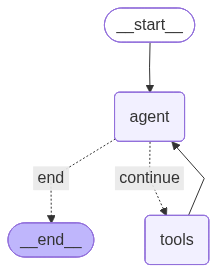

In [54]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow.set_entry_point("agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "agent",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
    # Finally we pass in a mapping.
    # The keys are strings, and the values are other nodes.
    # END is a special node marking that the graph should finish.
    # What will happen is we will call `should_continue`, and then the output of that
    # will be matched against the keys in this mapping.
    # Based on which one it matches, that node will then be called.
    {
        # If `tools`, then we call the tool node.
        "continue": "tools",
        # Otherwise we finish.
        "end": END,
    },
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow.add_edge("tools", "agent")

# Now we can compile and visualize our graph
graph = workflow.compile()

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## Use ReAct agent

In [55]:
# Helper function for formatting the stream nicely
def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


inputs = {"messages": [("user", "what is the weather in sf")]}
print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

what is the weather in sf


ResponseError: registry.ollama.ai/library/phi4:latest does not support tools (status code: 400)